# (a)

In [1]:
from ISLP import load_data
wage = load_data("Wage")
wage.head()

,year,age,maritl,race,education,region,jobclass,health,health_ins,logwage,wage
0,2006,18,1. Never Married,1. White,1. < HS Grad,2. Middle Atlantic,1. Industrial,1. <=Good,2. No,4.318063,75.043154
1,2004,24,1. Never Married,1. White,4. College Grad,2. Middle Atlantic,2. Information,2. >=Very Good,2. No,4.255273,70.476020
2,2003,45,2. Married,1. White,3. Some College,2. Middle Atlantic,1. Industrial,1. <=Good,1. Yes,4.875061,130.982177
3,2003,43,2. Married,3. Asian,4. College Grad,2. Middle Atlantic,2. Information,2. >=Very Good,1. Yes,5.041393,154.685293
4,2005,50,4. Divorced,1. White,2. HS Grad,2. Middle Atlantic,2. Information,1. <=Good,1. Yes,4.318063,75.043154


In [2]:
from sklearn.model_selection import KFold
from ISLP.models import ModelSpec as MS, poly
import statsmodels.api as sm
import numpy as np

kf = KFold(n_splits=5, shuffle=True, random_state=42)
mses = [] # mses scores in 2d array, one row per fold where each column is for each increasing order of degree
for train_idx, test_idx in kf.split(wage):
    train_df = wage.iloc[train_idx]
    test_df = wage.iloc[test_idx]
    specs = [MS([poly('age', degree=d)]) for d in range(1, 11)]
    Xs_train = [spec.fit_transform(train_df) for spec in specs]
    Xs_test = [spec.transform(test_df) for spec in specs]

    mse_degree = []
    for X_train, X_test in zip (Xs_train, Xs_test):
        model = sm.OLS(train_df['wage'], X_train).fit()
        predicted_wage = model.predict(X_test)
        mse = np.mean((test_df['wage'] - predicted_wage) ** 2)
        mse_degree.append(mse)
    mses.append(mse_degree)

In [3]:
mean_mses = np.mean(mses, axis=0)
optimal_d = np.argmin(mean_mses) + 1  
print(mean_mses)
print(optimal_d)

[1677.28943713 1600.84146712 1596.84954647 1596.6581845  1596.81407213
 1595.29197066 1595.68552903 1596.90320994 1597.14076285 1597.77100294]
6


In [4]:
from statsmodels.stats.anova import anova_lm
specs = [MS([poly('age', degree=d)]) for d in range(1, 11)]
Xs = [spec.fit_transform(wage) for spec in specs]
anova_lm(*[sm.OLS(wage['wage'], X_).fit() for X_ in Xs]) 

,df_resid,ssr,df_diff,ss_diff,F,Pr(>F)
0,2998.0,5.022216e+06,0.0,NaN,NaN,NaN
1,2997.0,4.793430e+06,1.0,228786.010128,143.763809,2.177738e-32
2,2996.0,4.777674e+06,1.0,15755.693664,9.900512,1.668545e-03
3,2995.0,4.771604e+06,1.0,6070.152124,3.814342,5.090855e-02
4,2994.0,4.770322e+06,1.0,1282.563017,0.805933,3.693976e-01
5,2993.0,4.766389e+06,1.0,3932.257665,2.470939,1.160743e-01
6,2992.0,4.763834e+06,1.0,2555.281281,1.605679,2.051988e-01
7,2991.0,4.763707e+06,1.0,126.668985,0.079596,7.778654e-01
8,2990.0,4.756703e+06,1.0,7004.317139,4.401350,3.599422e-02
9,2989.0,4.756701e+06,1.0,2.637537,0.001657,9.675292e-01


In [5]:
import pandas as pd
age_grid = pd.DataFrame({'age': np.linspace(wage['age'].min(), wage['age'].max(), 100)})
spec = MS([poly('age', degree=3)])
X_training = spec.fit_transform(wage)
Y_training = wage['wage']
X_grid = spec.transform(age_grid)
model = sm.OLS(Y_training, X_training).fit()

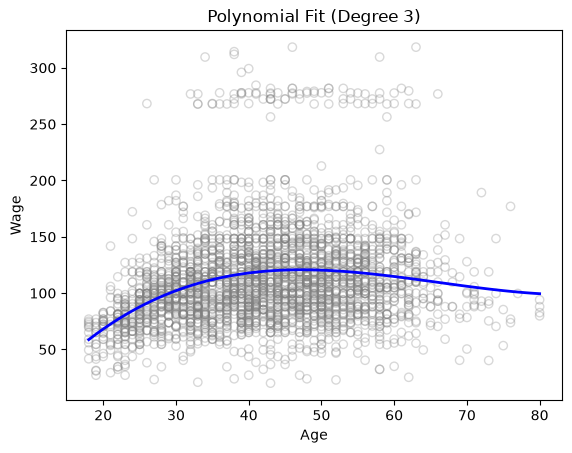

In [6]:
import matplotlib.pyplot as plt
grid_preds = model.predict(X_grid)

plt.scatter(wage['age'], wage['wage'], alpha=0.3, facecolors='none', edgecolors='gray')
plt.plot(age_grid['age'], grid_preds, color='blue', linewidth=2)
plt.xlabel('Age')
plt.ylabel('Wage')
plt.title('Polynomial Fit (Degree 3)')
plt.show()

# (b)

In [21]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

mses = []
for train_idx, test_idx in kf.split(wage):
    train_df = wage.iloc[train_idx]
    test_df = wage.iloc[test_idx]

    mse_fold = []
    for K in range(2, 11):
        train_cuts, bins = pd.cut(train_df['age'], bins=K, retbins=True)
        X_train = pd.get_dummies(train_cuts)
        Y_train = train_df['wage']
        bins[0] = 0 # to cover a lower value if it was not present in train df but there in test df
        bins[-1] = np.inf
        test_cuts = pd.cut(test_df['age'], bins=bins, include_lowest=True)
        X_test = pd.get_dummies(test_cuts)
        Y_test = test_df['wage']
        model = sm.OLS(Y_train, X_train).fit()
        prediction = model.predict(X_test)
        mse = np.mean((Y_test - prediction) ** 2)
        mse_fold.append(mse)
    mses.append(mse_fold)

In [23]:
mean_mses = np.mean(mses, axis=0)
mean_mses

array([1735.21442782, 1682.40023043, 1636.82836748, 1631.76994689,
       1623.09254411, 1614.74047699, 1603.2097179 , 1611.5608596 ,
       1605.9671673 ])

In [24]:
optimal_k = np.argmin(mean_mses) + 2 # +2 since we are starting the k at 2 
optimal_k

np.int64(8)

In [33]:
import pandas as pd
age_grid = np.linspace(wage['age'].min(), wage['age'].max(), 100)
age_cuts, bins = pd.cut(wage['age'], bins=optimal_k, retbins=True)
X_training = pd.get_dummies(age_cuts)
Y_training = wage['wage']
age_grid_cuts = pd.cut(age_grid, bins=bins, include_lowest=True)
X_grid = pd.get_dummies(age_grid_cuts)
model = sm.OLS(Y_training, X_training).fit()

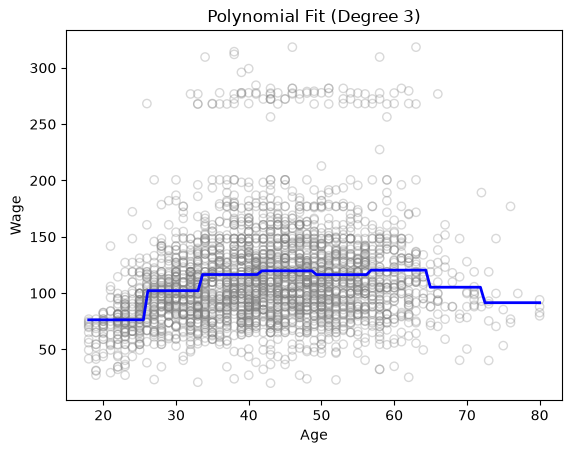

In [38]:
import matplotlib.pyplot as plt
grid_preds = model.predict(X_grid)

plt.scatter(wage['age'], wage['wage'], alpha=0.3, facecolors='none', edgecolors='gray')
plt.plot(age_grid, np.array(grid_preds), color='blue', linewidth=2)
plt.xlabel('Age')
plt.ylabel('Wage')
plt.title('Polynomial Fit (Degree 3)')
plt.show()